In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from collections import Counter
from wordcloud import WordCloud

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
data = {

"Review":[

"The room was clean and the staff were very friendly.",

"The food was terrible and service was slow.",

"Excellent location with beautiful rooms.",

"The bathroom was dirty and the bed was uncomfortable.",

"Amazing breakfast and helpful staff.",

"WiFi was very slow and parking was limited.",

"The swimming pool was clean and enjoyable.",

"The room service was disappointing.",

"Fantastic hotel with excellent facilities.",

"The air conditioner was not working properly."

],

"Sentiment":[

"Positive",

"Negative",

"Positive",

"Negative",

"Positive",

"Negative",

"Positive",

"Negative",

"Positive",

"Negative"

]

}

df = pd.DataFrame(data)

print(df)

                                              Review Sentiment
0  The room was clean and the staff were very fri...  Positive
1        The food was terrible and service was slow.  Negative
2           Excellent location with beautiful rooms.  Positive
3  The bathroom was dirty and the bed was uncomfo...  Negative
4               Amazing breakfast and helpful staff.  Positive
5        WiFi was very slow and parking was limited.  Negative
6         The swimming pool was clean and enjoyable.  Positive
7                The room service was disappointing.  Negative
8         Fantastic hotel with excellent facilities.  Positive
9      The air conditioner was not working properly.  Negative


In [3]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]','',text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review"].apply(clean_text)

print(df[["Review","Cleaned_Review"]])

                                              Review  \
0  The room was clean and the staff were very fri...   
1        The food was terrible and service was slow.   
2           Excellent location with beautiful rooms.   
3  The bathroom was dirty and the bed was uncomfo...   
4               Amazing breakfast and helpful staff.   
5        WiFi was very slow and parking was limited.   
6         The swimming pool was clean and enjoyable.   
7                The room service was disappointing.   
8         Fantastic hotel with excellent facilities.   
9      The air conditioner was not working properly.   

                         Cleaned_Review  
0             room clean staff friendly  
1            food terrible service slow  
2    excellent location beautiful rooms  
3      bathroom dirty bed uncomfortable  
4       amazing breakfast helpful staff  
5             wifi slow parking limited  
6         swimming pool clean enjoyable  
7            room service disappointing  
8  fa

In [4]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Review"])

y = df["Sentiment"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

In [7]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [8]:
y_pred = model.predict(X_test)

print("Predicted Sentiments")

print(y_pred)

Predicted Sentiments
['Positive' 'Negative']


In [9]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 1.0


In [10]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         1
    Positive       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [11]:
reviews=[

"Room was very clean and staff were helpful.",

"Food quality was poor.",

"Excellent swimming pool and gym.",

"Bathroom was dirty.",

"Very comfortable stay."

]

clean_reviews=[]

for review in reviews:

    clean_reviews.append(clean_text(review))

review_vector=vectorizer.transform(clean_reviews)

prediction=model.predict(review_vector)

for review,sentiment in zip(reviews,prediction):

    print(review)

    print("Sentiment :",sentiment)

    print()

Room was very clean and staff were helpful.
Sentiment : Positive

Food quality was poor.
Sentiment : Negative

Excellent swimming pool and gym.
Sentiment : Positive

Bathroom was dirty.
Sentiment : Negative

Very comfortable stay.
Sentiment : Negative



In [12]:
issues={

"Room":["room","bed"],

"Food":["food","breakfast"],

"Staff":["staff","service"],

"Cleanliness":["clean","dirty"],

"Amenities":["wifi","parking","pool","gym"]

}

def detect_issue(review):

    found=[]

    for category,words in issues.items():

        for word in words:

            if word in review:

                found.append(category)

                break

    return ",".join(found)

df["Issue"]=df["Cleaned_Review"].apply(detect_issue)

print(df[["Review","Issue"]])

                                              Review                   Issue
0  The room was clean and the staff were very fri...  Room,Staff,Cleanliness
1        The food was terrible and service was slow.              Food,Staff
2           Excellent location with beautiful rooms.                    Room
3  The bathroom was dirty and the bed was uncomfo...        Room,Cleanliness
4               Amazing breakfast and helpful staff.              Food,Staff
5        WiFi was very slow and parking was limited.               Amenities
6         The swimming pool was clean and enjoyable.   Cleanliness,Amenities
7                The room service was disappointing.              Room,Staff
8         Fantastic hotel with excellent facilities.                        
9      The air conditioner was not working properly.                        


In [13]:
all_words=" ".join(df["Cleaned_Review"])

word_list=all_words.split()

word_freq=Counter(word_list)

print(word_freq.most_common(10))

[('room', 2), ('clean', 2), ('staff', 2), ('service', 2), ('slow', 2), ('excellent', 2), ('friendly', 1), ('food', 1), ('terrible', 1), ('location', 1)]


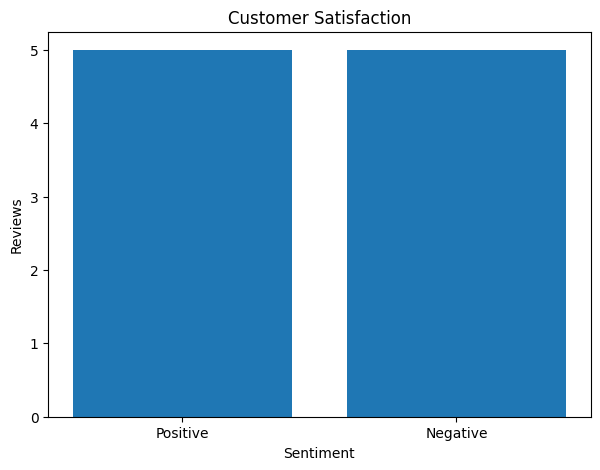

In [14]:
sentiment_count=df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(sentiment_count.index,sentiment_count.values)

plt.title("Customer Satisfaction")

plt.xlabel("Sentiment")

plt.ylabel("Reviews")

plt.show()

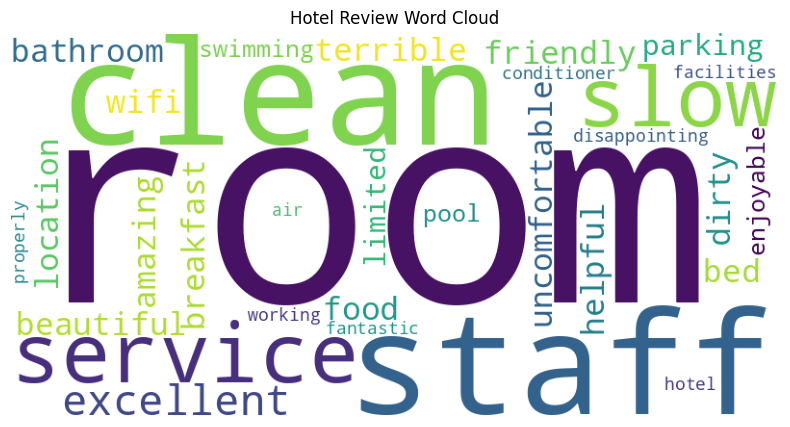

In [15]:
wordcloud=WordCloud(

width=800,

height=400,

background_color="white"

).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Hotel Review Word Cloud")

plt.show()

In [16]:
positive=len(df[df["Sentiment"]=="Positive"])

negative=len(df[df["Sentiment"]=="Negative"])

print("Customer Satisfaction Report")

print("Positive Reviews :",positive)

print("Negative Reviews :",negative)

print()

print("Issue Frequency")

print(df["Issue"].value_counts())

Customer Satisfaction Report
Positive Reviews : 5
Negative Reviews : 5

Issue Frequency
Issue
Food,Staff                2
                          2
Room                      1
Room,Staff,Cleanliness    1
Room,Cleanliness          1
Amenities                 1
Cleanliness,Amenities     1
Room,Staff                1
Name: count, dtype: int64
